# Clasificadores con clases desbalanceadas asignando pesos

En Machine Learning, clases desbalanceadas se refieren a un problema en clasificación cuando las clases en los datos de entrenamiento no están representadas de manera equitativa. Es decir, una clase tiene muchas más muestras que la otra(s).

Por ejemplo, en un modelo de detección de fraude con tarjetas de crédito:

* Clase "Fraude" → 1% de los datos
* Clase "No Fraude" → 99% de los datos

## ¿Por qué es un problema?

Si el modelo simplemente predice siempre la clase mayoritaria ("No Fraude"), tendrá una precisión del 99%, pero será inútil porque no detecta fraudes correctamente.

## Ejemplo en Python

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

In [17]:
def matriz_de_confusion(clases_reales, clases_predichas, titulo, cols):
    """Visualiza la matriz de confusion"""

    matriz = confusion_matrix(clases_reales, clases_predichas)
    accuracy = accuracy_score(clases_reales, clases_predichas)

    plt.figure(figsize=(4, 4))
    matriz = pd.DataFrame(matriz, columns=cols)
    plt.matshow(matriz, cmap="summer", vmin=0, vmax=20, fignum=1)
    plt.xticks(range(len(matriz.columns)), matriz.columns, rotation=45)
    plt.yticks(range(len(matriz.columns)), matriz.columns)
    etiquetas = (("Verdaderos\nnegativos", "Falsos\npositivos"),
                 ("Falsos\nnegativos", "Verdaderos\npositivos"))
    plt.text(1.60, -0.30, titulo, fontsize=25, c="red")
    plt.text(2.1, 0.10, "Accuracy: %0.2f" % accuracy, fontsize=20)
    for i in range(len(matriz.columns)):
        for j in range(len(matriz.columns)):
            plt.text(i, j + 0.14, str(matriz.iloc[i, j]),
                     fontsize=30, ha="center", va="center")
            plt.text(i, j - 0.25, etiquetas[i][j],
                     fontsize=11.5, ha="center", va="center")           
    plt.show()

### Datos cáncer de mama

#### Distribución de clases (desbalanceada)

In [4]:
# los datos ya se encuentran escalados
info = np.loadtxt("../datos/cancer.csv", delimiter=",", unpack=True)
info.shape

(31, 330)

In [7]:
info

array([[0.6585, 0.6468, 0.7206, ..., 0.3385, 0.2206, 0.2534],
       [0.5008, 0.7104, 0.3129, ..., 0.2867, 0.2025, 0.3452],
       [0.629 , 0.6283, 0.6786, ..., 0.3157, 0.211 , 0.2411],
       ...,
       [0.3201, 0.5233, 0.2897, ..., 0.3416, 0.422 , 0.2578],
       [0.13  , 0.226 , 0.1042, ..., 0.2331, 0.3918, 0.2364],
       [1.    , 1.    , 1.    , ..., 0.    , 0.    , 0.    ]])

In [9]:
# 30 caracteristicas: radio, textura, area, entre otros
datos = info[:-1].T

# 0: SANO, 1: ENFERMO
clases = info[-1]

In [10]:
datos, clases

(array([[0.6585, 0.5008, 0.629 , ..., 0.6724, 0.3201, 0.13  ],
        [0.6468, 0.7104, 0.6283, ..., 0.8198, 0.5233, 0.226 ],
        [0.7206, 0.3129, 0.6786, ..., 0.6933, 0.2897, 0.1042],
        ...,
        [0.3385, 0.2867, 0.3157, ..., 0.237 , 0.3416, 0.2331],
        [0.2206, 0.2025, 0.211 , ..., 0.2831, 0.422 , 0.3918],
        [0.2534, 0.3452, 0.2411, ..., 0.2168, 0.2578, 0.2364]]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

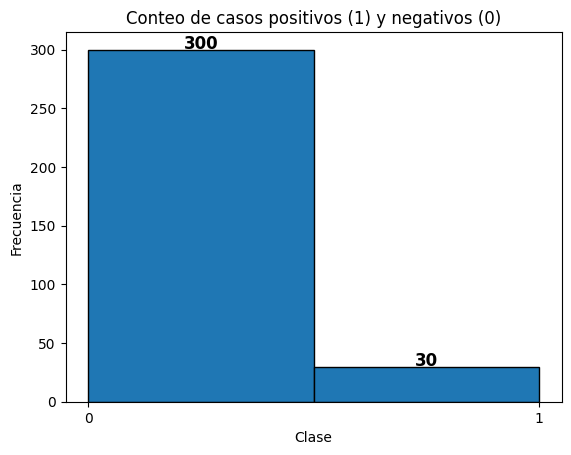

In [15]:
# Crear el histograma con 2 bins
counts, bins, patches = plt.hist(clases, bins=2, edgecolor='black', align='mid')

# Agregar las etiquetas de cantidad encima de cada barra
for count, bin_center in zip(counts, (bins[:-1] + bins[1:]) / 2):
    plt.text(bin_center, count + 1, str(int(count)), ha='center', fontsize=12, fontweight='bold')

# Etiquetas y título
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.title("Conteo de casos positivos (1) y negativos (0)")
plt.xticks([0, 1]) 

plt.show()

### Clasificador Regresión Logística

#### Asignación de Pesos a Clases

En este caso, utilizaremos regresión logística para desarrollar el modelo de clasificación binaria.

Como hemos visto, claramente este es un ejemplo de clases desbalanceadas, ya que tenemos una gran cantidad de observaciones para el caso negativo o sanos, y muchos menos para el caso positivo o con cáncer. Entonces, para que nuestro algoritmo clasifique los futuros casos positivos de manera más correcta y con menos errores, aquí recurrimos a la **asignación de pesos** para corregir dicho desbalanceo.

Esta asignación implica indicar qué tanto se penaliza una predicción incorrecta para una clase u otra. 
Por ejemplo, se puede penalizar más fuertemente los falsos negativos para los casos de personas con cáncer realmente pero que fueron predichas como sanas.

En los siguientes modelos vemos 4 posibilidades:

* El modelo común, sin realizar cambios respecto al balanceo de las clases

* El modelo con pesos, asignando nosotros 'a mano' cuánto se penalizan los errores cometidos para falsos positivos de una clase u otra.

* El modelo balanceado automáticamente por la opción 'balanced' que nos provee `scikit-learn`

* El modelo balanceado por nosotros aplicando el mismo cálcilo de los pesos que realiza la opción 'balanced'

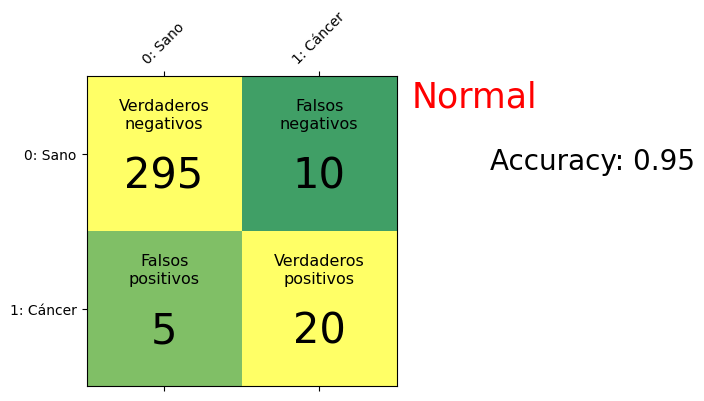

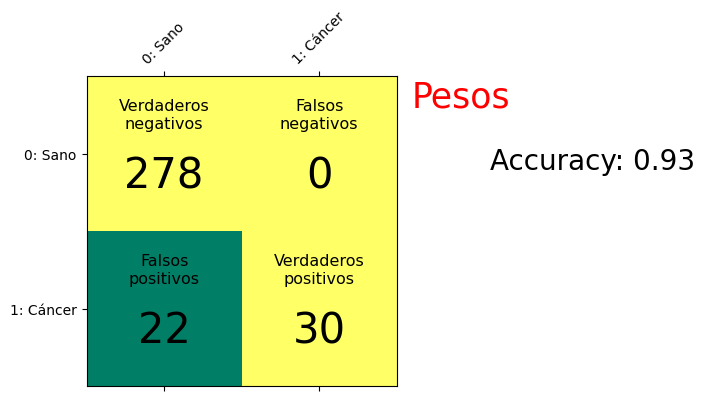

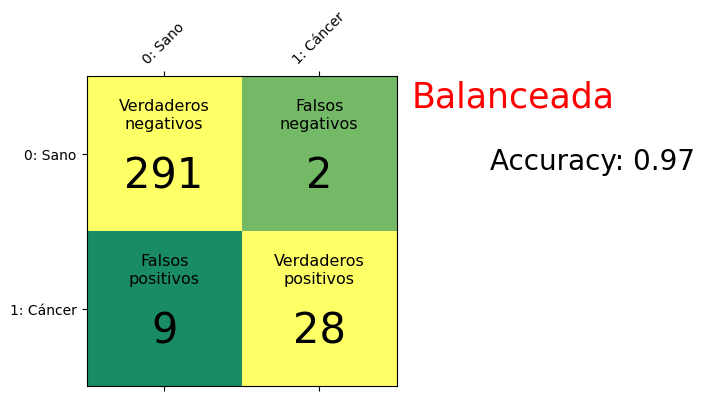

0.55 5.5


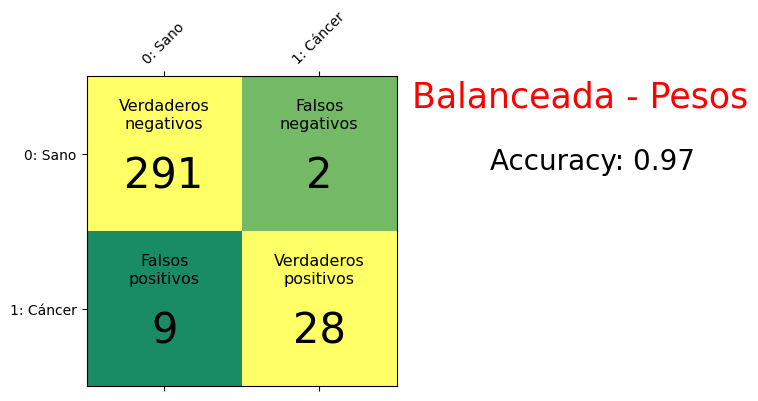

In [23]:
modelo = LogisticRegression().fit(datos, clases)
matriz_de_confusion(clases, modelo.predict(datos), "Normal", ["0: Sano", "1: Cáncer"])


modelo = LogisticRegression(class_weight={0 : 1, 1 : 100}).fit(datos, clases)
matriz_de_confusion(clases, modelo.predict(datos), "Pesos", ["0: Sano", "1: Cáncer"])


modelo = LogisticRegression(class_weight="balanced").fit(datos, clases)
matriz_de_confusion(clases, modelo.predict(datos), "Balanceada", ["0: Sano", "1: Cáncer"])


# Cálculo 'a mano' de los pesos que la heuristica 'balanced' asigna a cada clase
# La formula sería:
# cantidad total de observaciones / (nro de clases x cantidad de una de las clases)
print(330 / (2 * 300), 330 / (2 * 30)) # esto nos da: 0.55  5.5

modelo = LogisticRegression(class_weight={0: 0.55, 1: 5.5}).fit(datos, clases)
matriz_de_confusion(clases, modelo.predict(datos), "Balanceada - Pesos", ["0: Sano", "1: Cáncer"])
